<a href="https://colab.research.google.com/github/proshenjitbarua06-dot/skill-morph/blob/main/Ensemble_and_Comparative_Analysis_of_Machine_Learning_Models_for_Multi_Class_Epileptic_Seizure_Detection_Using_16_Channel_EEG_Signals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
# ─── Install Dependencies ───
!pip install -q xgboost lightgbm catboost scikit-learn pandas matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.1 MB/s eta 0:00:00


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.multiclass import OneVsRestClassifier
import warnings
warnings.filterwarnings('ignore')

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [6]:
# Load dataset
df = pd.read_csv('/content/drive/MyDrive/Dataset/BEED_Data.csv')
print("Dataset Shape:", df.shape)
print("\nClass Distribution:")
print(df['y'].value_counts())

# Check for missing values
print("\nMissing Values:", df.isnull().sum().sum())

Dataset Shape: (8000, 17)

Class Distribution:
y
0    2000
1    2000
2    2000
3    2000
Name: count, dtype: int64

Missing Values: 0



=== Starting EDA ===


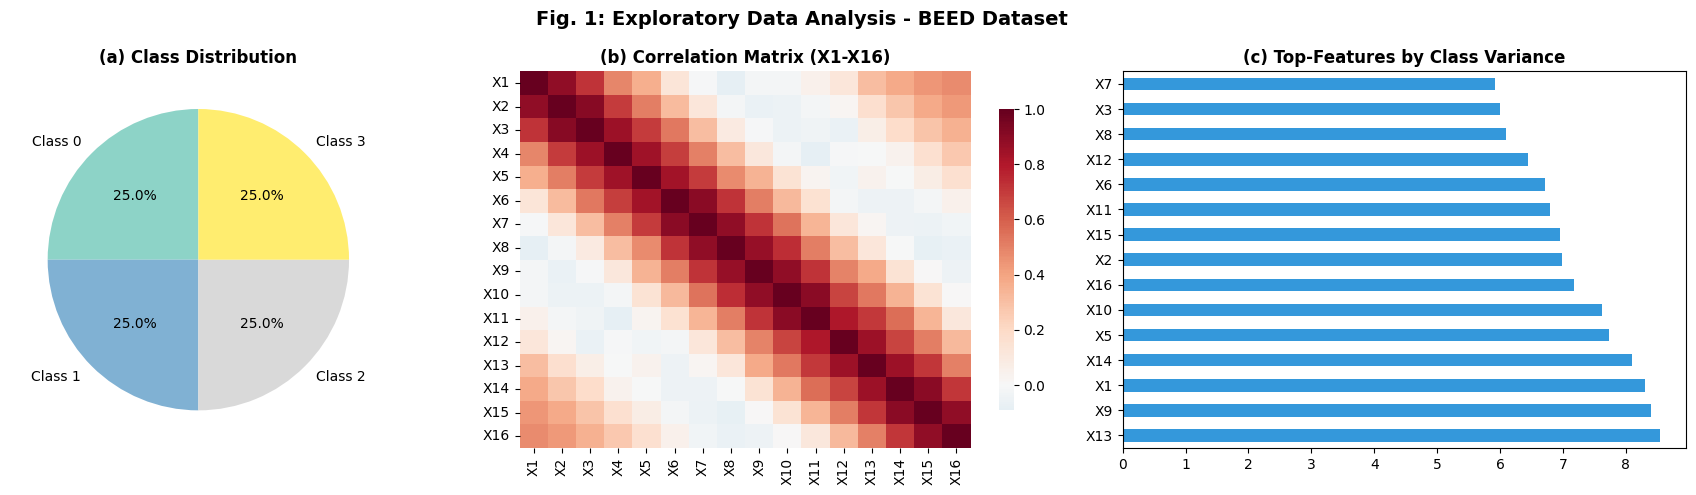

In [13]:
# ─── Exploratory Data Analysis (EDA) ───
print("\n=== Starting EDA ===")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Class Distribution
class_counts = df['y'].value_counts().sort_index()
labels = [f'Class {i}' for i in range(4)]
axes[0].pie(class_counts, labels=labels, autopct='%1.1f%%',
            colors=plt.cm.Set3(np.linspace(0, 1, 4)), startangle=90)
axes[0].set_title("(a) Class Distribution", fontweight="bold")

# (b) Correlation Heatmap (Channels)
corr = df.iloc[:, :16].corr()
sns.heatmap(corr, cmap="RdBu_r", center=0, ax=axes[1], cbar_kws={"shrink": 0.8})
axes[1].set_title("(b) Correlation Matrix (X1-X16)", fontweight="bold")

# (c) Top Features by Class Variance
feature_means = df.groupby('y').mean().T
mean_diff = feature_means.std(axis=1).sort_values(ascending=False).head(15)
mean_diff.plot.barh(ax=axes[2], color="#3498db")
axes[2].set_title("(c) Top-Features by Class Variance", fontweight="bold")

plt.suptitle("Fig. 1: Exploratory Data Analysis - BEED Dataset", fontsize=14, fontweight="bold")
plt.tight_layout()

plt.show()


In [17]:
X = df.drop('y', axis=1)
y = df['y']

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Scaling (important for SVM, KNN, Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Data Preprocessed | Train:", X_train.shape, "Test:", X_test.shape)

✅ Data Preprocessed | Train: (6400, 16) Test: (1600, 16)


In [18]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel='rbf', probability=True, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=400, random_state=42, eval_metric='mlogloss'),
    "LightGBM": LGBMClassifier(n_estimators=400, random_state=42, verbose=-1),
    "CatBoost": CatBoostClassifier(iterations=400, random_state=42, verbose=0)
}

# Ensemble Model (Voting Classifier)
ensemble = VotingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=400, random_state=42)),
        ('xgb', XGBClassifier(n_estimators=400, random_state=42, eval_metric='mlogloss')),
        ('lgb', LGBMClassifier(n_estimators=400, random_state=42, verbose=-1)),
        ('cat', CatBoostClassifier(iterations=400, random_state=42, verbose=0))
    ],
    voting='soft'
)


=== Logistic Regression ===
Accuracy: 0.4544 | Precision: 0.4833 | Recall: 0.4544 | F1: 0.4609

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.51      0.61       400
           1       0.49      0.59      0.54       400
           2       0.36      0.38      0.37       400
           3       0.31      0.34      0.32       400

    accuracy                           0.45      1600
   macro avg       0.48      0.45      0.46      1600
weighted avg       0.48      0.45      0.46      1600



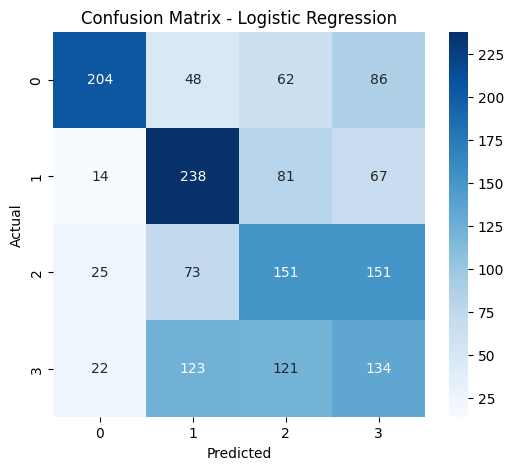


=== KNN ===
Accuracy: 0.9706 | Precision: 0.9713 | Recall: 0.9706 | F1: 0.9707

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99       400
           1       0.98      0.95      0.97       400
           2       0.96      0.97      0.97       400
           3       0.94      0.99      0.96       400

    accuracy                           0.97      1600
   macro avg       0.97      0.97      0.97      1600
weighted avg       0.97      0.97      0.97      1600



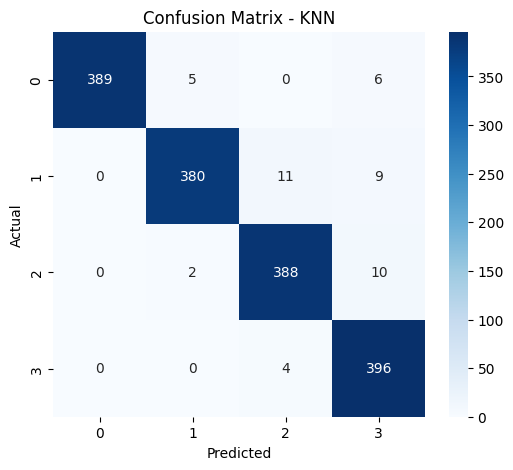


=== SVM ===
Accuracy: 0.7444 | Precision: 0.7731 | Recall: 0.7444 | F1: 0.7310

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       400
           1       0.81      0.71      0.76       400
           2       0.57      0.93      0.70       400
           3       0.72      0.35      0.47       400

    accuracy                           0.74      1600
   macro avg       0.77      0.74      0.73      1600
weighted avg       0.77      0.74      0.73      1600



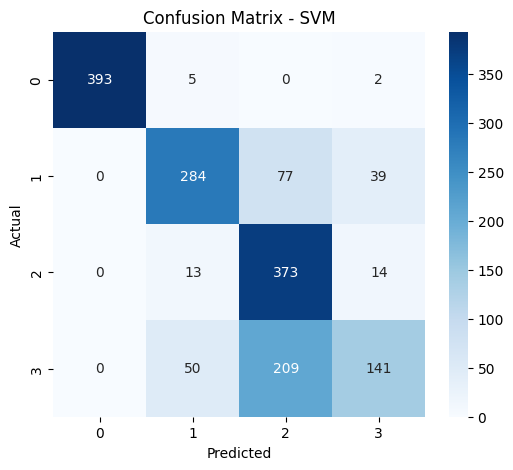


=== Random Forest ===
Accuracy: 0.9656 | Precision: 0.9658 | Recall: 0.9656 | F1: 0.9657

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       400
           1       0.98      0.97      0.98       400
           2       0.94      0.95      0.95       400
           3       0.95      0.94      0.94       400

    accuracy                           0.97      1600
   macro avg       0.97      0.97      0.97      1600
weighted avg       0.97      0.97      0.97      1600



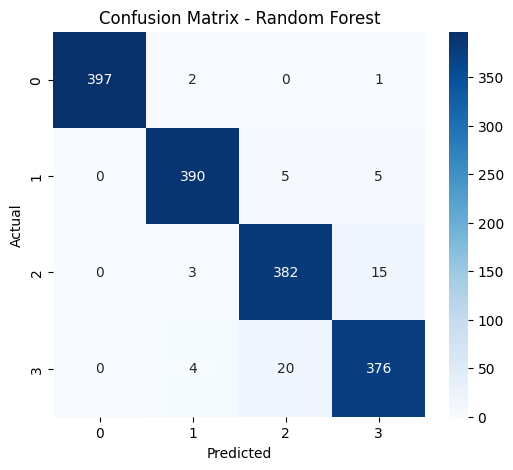


=== XGBoost ===
Accuracy: 0.9781 | Precision: 0.9782 | Recall: 0.9781 | F1: 0.9782

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       400
           1       0.99      0.98      0.98       400
           2       0.97      0.96      0.97       400
           3       0.96      0.97      0.97       400

    accuracy                           0.98      1600
   macro avg       0.98      0.98      0.98      1600
weighted avg       0.98      0.98      0.98      1600



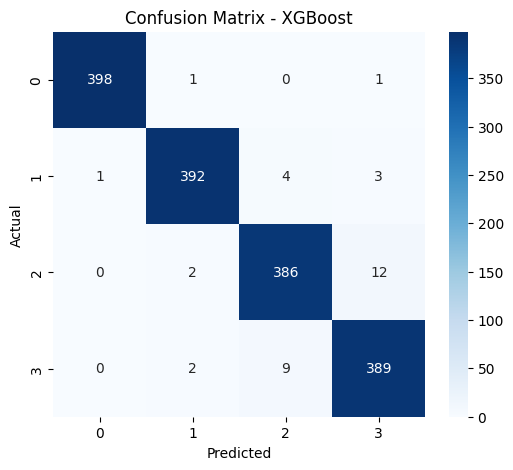


=== LightGBM ===
Accuracy: 0.9856 | Precision: 0.9857 | Recall: 0.9856 | F1: 0.9856

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       400
           1       1.00      0.98      0.99       400
           2       0.97      0.97      0.97       400
           3       0.97      0.99      0.98       400

    accuracy                           0.99      1600
   macro avg       0.99      0.99      0.99      1600
weighted avg       0.99      0.99      0.99      1600



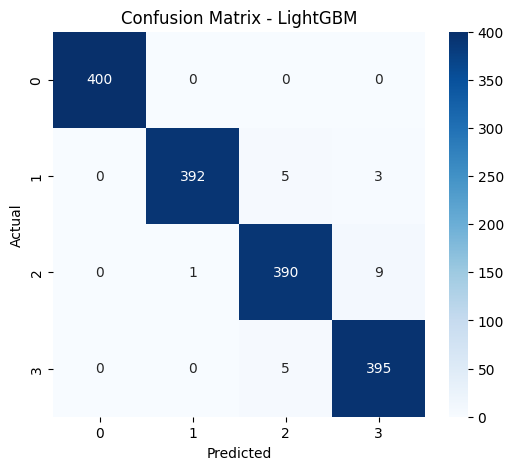


=== CatBoost ===
Accuracy: 0.9700 | Precision: 0.9702 | Recall: 0.9700 | F1: 0.9701

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       400
           1       0.98      0.97      0.97       400
           2       0.95      0.96      0.96       400
           3       0.95      0.95      0.95       400

    accuracy                           0.97      1600
   macro avg       0.97      0.97      0.97      1600
weighted avg       0.97      0.97      0.97      1600



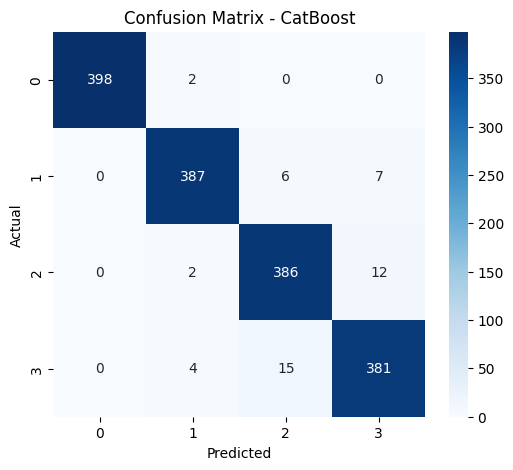


=== Ensemble (Voting) ===
Accuracy: 0.9844 | Precision: 0.9845 | Recall: 0.9844 | F1: 0.9844

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       400
           1       0.99      0.98      0.99       400
           2       0.97      0.97      0.97       400
           3       0.97      0.98      0.98       400

    accuracy                           0.98      1600
   macro avg       0.98      0.98      0.98      1600
weighted avg       0.98      0.98      0.98      1600



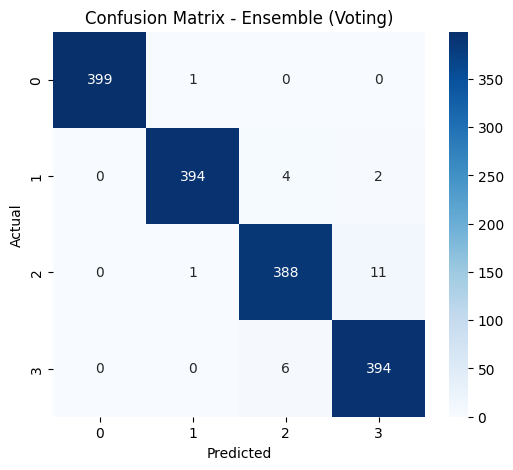

In [20]:
results = []

def evaluate_model(name, model, X_tr, X_te):
    if name in ["Logistic Regression", "KNN", "SVM"]:
        model.fit(X_tr, y_train)
        pred = model.predict(X_te)
    else:
        model.fit(X_train, y_train)  # Tree models handle unscaled data well
        pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred, average='macro')
    rec = recall_score(y_test, pred, average='macro')
    f1 = f1_score(y_test, pred, average='macro')

    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })

    print(f"\n=== {name} ===")
    print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# Train Individual Models
for name, model in models.items():
    evaluate_model(name, model, X_train_scaled, X_test_scaled)

# Train Ensemble
evaluate_model("Ensemble (Voting)", ensemble, X_train, X_test)


📊 Model Comparison Table:
                 Model  Accuracy  Precision  Recall  F1-Score
0  Logistic Regression    0.4544     0.4833  0.4544    0.4609
1                  KNN    0.9706     0.9713  0.9706    0.9707
2                  SVM    0.7444     0.7731  0.7444    0.7310
3        Random Forest    0.9656     0.9658  0.9656    0.9657
4              XGBoost    0.9781     0.9782  0.9781    0.9782
5             LightGBM    0.9856     0.9857  0.9856    0.9856
6             CatBoost    0.9700     0.9702  0.9700    0.9701
7    Ensemble (Voting)    0.9844     0.9845  0.9844    0.9844


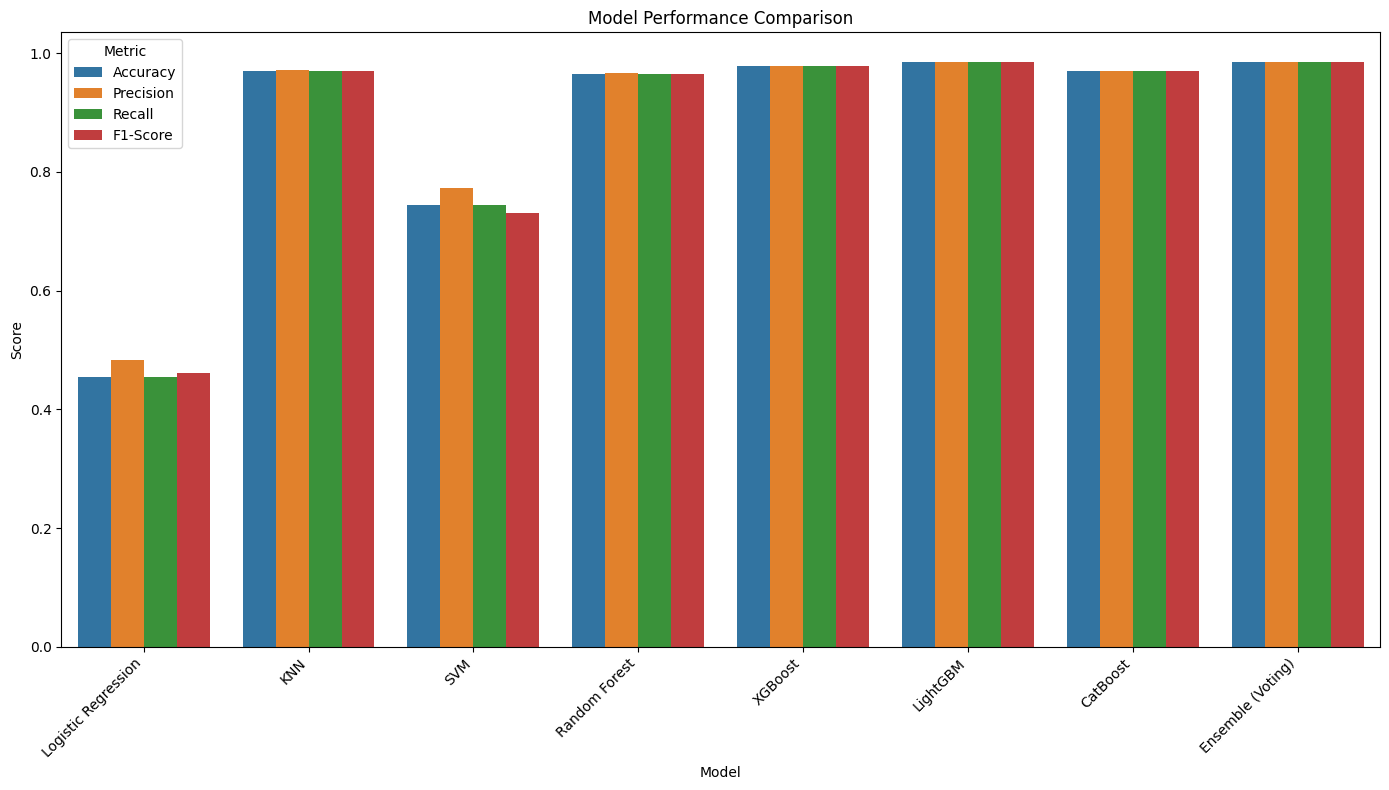


 Best Model: LightGBM with F1-Score: 0.9856


In [21]:
results_df = pd.DataFrame(results)
print("\n📊 Model Comparison Table:")
print(results_df.round(4))

# Bar Plot Comparison
plt.figure(figsize=(14, 8))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
results_melt = pd.melt(results_df, id_vars=['Model'], value_vars=metrics)

sns.barplot(x='Model', y='value', hue='variable', data=results_melt)
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

# Highlight Best Model
best_model = results_df.loc[results_df['F1-Score'].idxmax()]
print(f"\n Best Model: {best_model['Model']} with F1-Score: {best_model['F1-Score']:.4f}")